In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report
)
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Robust project root detection
# ---------------------------------------------------------
def find_project_root(start_path: Path) -> Path:
    for parent in [start_path] + list(start_path.parents):
        if (parent / "data").exists() and (parent / "scripts").exists():
            return parent
    raise RuntimeError("Project root not found.")

PROJECT_ROOT = find_project_root(Path.cwd())

DATA_LABELS_DIR = PROJECT_ROOT / "data" / "labels"
MODEL_DIR = PROJECT_ROOT / "models"

print("Project root:", PROJECT_ROOT)


Project root: c:\Trading\Projects\ES_AI_Project


In [2]:
df = pd.read_csv(DATA_LABELS_DIR / "labeled.csv")

model = xgb.XGBClassifier()
model.load_model(MODEL_DIR / "xgb_model.json")

FEATURE_COLS = [c for c in df.columns if c not in ["Time","FutureClose","FutureRet","ShortSuccess"]]

X = df[FEATURE_COLS].astype(float)
y = df["ShortSuccess"].astype(int)


In [3]:
y_prob = model.predict_proba(X)[:,1]


In [4]:
y_pred = (y_prob > 0.5).astype(int)

print("Accuracy:", accuracy_score(y, y_pred))
print("Precision:", precision_score(y, y_pred))
print("Recall:", recall_score(y, y_pred))
print("F1:", f1_score(y, y_pred))

print("\nClassification Report:")
print(classification_report(y, y_pred))


Accuracy: 0.823545282849177
Precision: 0.7778394890308248
Recall: 0.8464792988818374
F1: 0.8107091172214183

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.81      0.83     12311
           1       0.78      0.85      0.81      9927

    accuracy                           0.82     22238
   macro avg       0.82      0.83      0.82     22238
weighted avg       0.83      0.82      0.82     22238



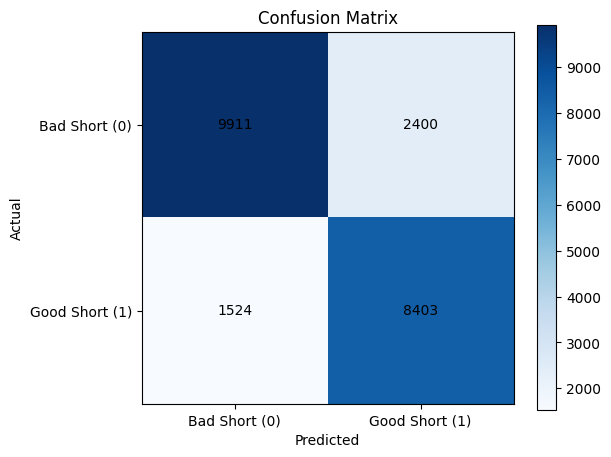

In [5]:
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ["Bad Short (0)", "Good Short (1)"])
plt.yticks([0,1], ["Bad Short (0)", "Good Short (1)"])
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center", color="black")

plt.show()


In [ ]:
fpr, tpr, _ = roc_curve(y, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [ ]:
thresholds = np.arange(0.1, 0.91, 0.05)
results = []

for t in thresholds:
    pred = (y_prob > t).astype(int)
    results.append([
        t,
        accuracy_score(y, pred),
        precision_score(y, pred),
        recall_score(y, pred),
        f1_score(y, pred)
    ])

eval_df = pd.DataFrame(results, columns=["Threshold","Acc","Prec","Rec","F1"])
eval_df


In [8]:
# Threshold sweep to compute F1 across thresholds
thresholds = np.arange(0.1, 0.91, 0.05)
results = []

for t in thresholds:
    pred = (y_prob > t).astype(int)
    results.append([
        t,
        accuracy_score(y, pred),
        precision_score(y, pred),
        recall_score(y, pred),
        f1_score(y, pred)
    ])

eval_df = pd.DataFrame(results, columns=["Threshold","Acc","Prec","Rec","F1"])
display(eval_df)


,Threshold,Acc,Prec,Rec,F1
0,0.10,0.463216,0.454021,0.999698,0.624445
1,0.15,0.497707,0.470437,0.996273,0.639095
2,0.20,0.546227,0.495856,0.988415,0.660407
3,0.25,0.603382,0.530106,0.981767,0.688471
4,0.30,0.671238,0.578052,0.975824,0.726026
5,0.35,0.738646,0.636557,0.966153,0.767464
6,0.40,0.792967,0.696667,0.949733,0.803751
7,0.45,0.826108,0.750703,0.913972,0.824331
8,0.50,0.823545,0.777839,0.846479,0.810709
9,0.55,0.795170,0.785988,0.743628,0.764222


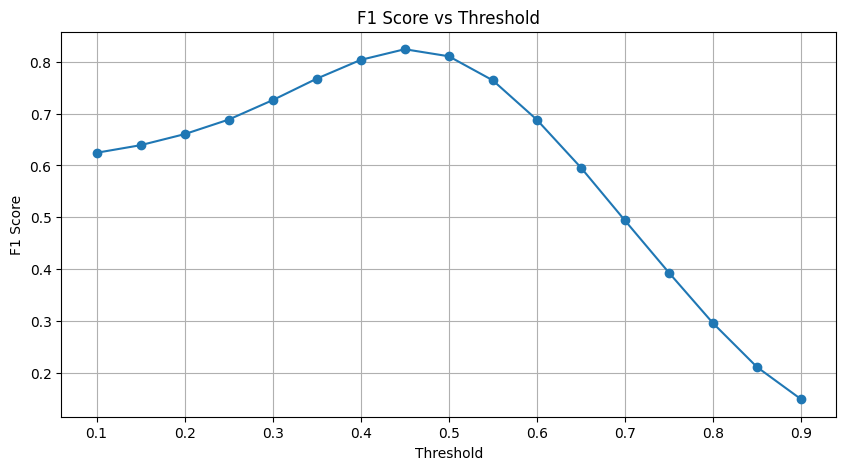

In [9]:
plt.figure(figsize=(10,5))
plt.plot(eval_df["Threshold"], eval_df["F1"], marker="o")
plt.title("F1 Score vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.grid(True)
plt.show()
